In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import json

# 读取原始CSV文件
file_path = "E:/EPFL_Courses/Data_Visualization/lyrical_emotion_trends.csv"
df = pd.read_csv(file_path)

# 数据清洗
print(f"原始数据行数: {len(df)}")
df = df.dropna(subset=['language', 'publicationYear', 'valence_mean', 'arousal_mean', 'dominance_mean'])
print(f"清洗后数据行数: {len(df)}")

# 限制年份范围，舍弃2024年及以后的数据
df = df[df['publicationYear'] < 2024]
print(f"限制年份后数据行数: {len(df)}")

# 查看语言分布
language_counts = df['language'].value_counts()
print("\n各语言的歌曲数量:")
print(language_counts)

# 只保留至少有30首歌的语言，确保数据足够做时间序列分析
min_songs = 30
valid_languages = language_counts[language_counts >= min_songs].index.tolist()
print(f"\n有效语言数量（至少{min_songs}首歌）: {len(valid_languages)}")
print(valid_languages)

# 过滤数据集，只保留有效语言
df_filtered = df[df['language'].isin(valid_languages)]

# 创建存储处理后数据的目录
output_dir = "E:/EPFL_Courses/Data_Visualization/processed_data"
os.makedirs(output_dir, exist_ok=True)

# 创建结果汇总数据框
result_data = []

# 跟踪有效的语言（有足够的数据点进行回归分析）
languages_with_data = set()

# 处理每种语言和情感指标的组合
for language in valid_languages:
    # 筛选该语言的数据
    lang_data = df_filtered[df_filtered['language'] == language]
    
    # 对于每个情感指标
    for emotion in ['valence_mean', 'arousal_mean', 'dominance_mean']:
        # 按年份分组并计算平均值
        yearly_stats = lang_data.groupby('publicationYear')[emotion].agg(['mean', 'count', 'std']).reset_index()
        
        # 只保留至少有3首歌的年份，确保平均值有意义
        yearly_stats = yearly_stats[yearly_stats['count'] >= 3]
        
        if len(yearly_stats) >= 5:  # 至少需要5个数据点进行回归分析
            # 将此语言添加到有效语言集合
            languages_with_data.add(language)
            
            # 准备回归数据
            x = yearly_stats['publicationYear'].values
            y = yearly_stats['mean'].values
            
            # 线性回归
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            
            # 计算回归线的y值
            regression_line = [slope * year + intercept for year in x]
            
            # 创建结果字典，包含所有必要的数据点和回归信息
            for i, year in enumerate(x):
                result_data.append({
                    'language': language,
                    'emotion': emotion,
                    'year': int(year),
                    'value': float(y[i]),
                    'count': int(yearly_stats['count'].iloc[i]),
                    'std': float(yearly_stats['std'].iloc[i]) if not pd.isna(yearly_stats['std'].iloc[i]) else 0,
                    'slope': float(slope),
                    'intercept': float(intercept),
                    'r_value': float(r_value),
                    'p_value': float(p_value),
                    'predicted': float(regression_line[i])
                })
            
            # 创建并保存语言+情感的可视化数据为CSV
            emotion_short = emotion.split('_')[0]  # 简化指标名称
            viz_data = pd.DataFrame({
                'year': x,
                'value': y,
                'count': yearly_stats['count'].values,
                'std': yearly_stats['std'].values,
                'predicted': regression_line
            })
            viz_filename = f"{language}_{emotion_short}.csv"
            viz_data.to_csv(os.path.join(output_dir, viz_filename), index=False)
            
            # 创建示例图作为参考
            plt.figure(figsize=(10, 6))
            plt.scatter(x, y, alpha=0.7)
            plt.plot(x, regression_line, color='red')
            plt.title(f"{language}: {emotion} (slope: {slope:.5f})")
            plt.xlabel('publication year')
            plt.ylabel(f'{emotion}')
            plt.ylim(-1, 1)
            plt.savefig(os.path.join(output_dir, f"{language}_{emotion_short}.png"))
            plt.close()

# 如果没有有效数据，提供提示
if not result_data:
    print("没有足够的数据点来生成任何结果。请考虑减少min_songs或放宽过滤条件。")
    exit()

# 将所有结果保存为一个CSV文件
result_df = pd.DataFrame(result_data)
result_df.to_csv(os.path.join(output_dir, "emotion_trends_by_language.csv"), index=False)

# 创建语言和情感指标的汇总数据，便于前端选择
language_summary = {}

# 只处理有有效数据的语言
for language in languages_with_data:
    lang_data = result_df[result_df['language'] == language]
    
    # 确保该语言有数据
    if not lang_data.empty:
        emotions_available = lang_data['emotion'].unique().tolist()
        
        # 安全地获取年份范围
        try:
            years_range = [
                int(lang_data['year'].min()),
                int(lang_data['year'].max())
            ]
        except (ValueError, TypeError):
            print(f"警告: {language}的年份数据有问题，跳过")
            continue
            
        language_summary[language] = {
            'emotions': emotions_available,
            'years_range': years_range,
            'song_count': int(language_counts[language])
        }

# 保存语言汇总信息为JSON
with open(os.path.join(output_dir, "language_summary.json"), 'w') as f:
    json.dump(language_summary, f, indent=2)

# 创建斜率排序表，显示哪些语言在各情感指标上变化最大
slope_summary = result_df.drop_duplicates(['language', 'emotion'])[['language', 'emotion', 'slope', 'p_value']]
for emotion in ['valence_mean', 'arousal_mean', 'dominance_mean']:
    emotion_slopes = slope_summary[slope_summary['emotion'] == emotion].sort_values('slope', ascending=False)
    if not emotion_slopes.empty:
        print(f"\n{emotion} 斜率排序:")
        print(emotion_slopes[['language', 'slope', 'p_value']].head(10))
    else:
        print(f"\n{emotion}没有足够的数据进行斜率排序")

print(f"\n处理完成! 所有数据已保存到: {output_dir}")

原始数据行数: 1679972
清洗后数据行数: 1026275
限制年份后数据行数: 1026179

各语言的歌曲数量:
language
english       784471
spanish        72335
french         35738
german         33813
italian        31035
portuguese     24554
dutch           7011
swedish         6189
polish          6132
finnish         5269
turkish         3202
norwegian       2769
slovak          2448
croatian        1826
danish          1626
hausa           1119
hungarian       1100
indonesian       979
latin            620
cebuano          578
tagalog          473
slovene          456
lithuanian       427
romanian         403
latvian          260
hawaiian         228
icelandic        217
czech            183
somali           171
estonian         165
welsh            142
swahili          117
albanian          74
vietnamese        44
azeri              5
Name: count, dtype: int64

有效语言数量（至少30首歌）: 34
['english', 'spanish', 'french', 'german', 'italian', 'portuguese', 'dutch', 'swedish', 'polish', 'finnish', 'turkish', 'norwegian', 'slovak', 'cro

原始数据行数: 1679972
清洗后数据行数: 1026275
限制年份后数据行数: 1026179

各语言的歌曲数量:
language
english       784471
spanish        72335
french         35738
german         33813
italian        31035
portuguese     24554
dutch           7011
swedish         6189
polish          6132
finnish         5269
turkish         3202
norwegian       2769
slovak          2448
croatian        1826
danish          1626
hausa           1119
hungarian       1100
indonesian       979
latin            620
cebuano          578
tagalog          473
slovene          456
lithuanian       427
romanian         403
latvian          260
hawaiian         228
icelandic        217
czech            183
somali           171
estonian         165
welsh            142
swahili          117
albanian          74
vietnamese        44
azeri              5
Name: count, dtype: int64

筛选后保留的语言数量: 33
筛选后的数据行数: 1026130

筛选后各语言的歌曲数量:
language
english       784471
spanish        72335
french         35738
german         33813
italian        31035
portu

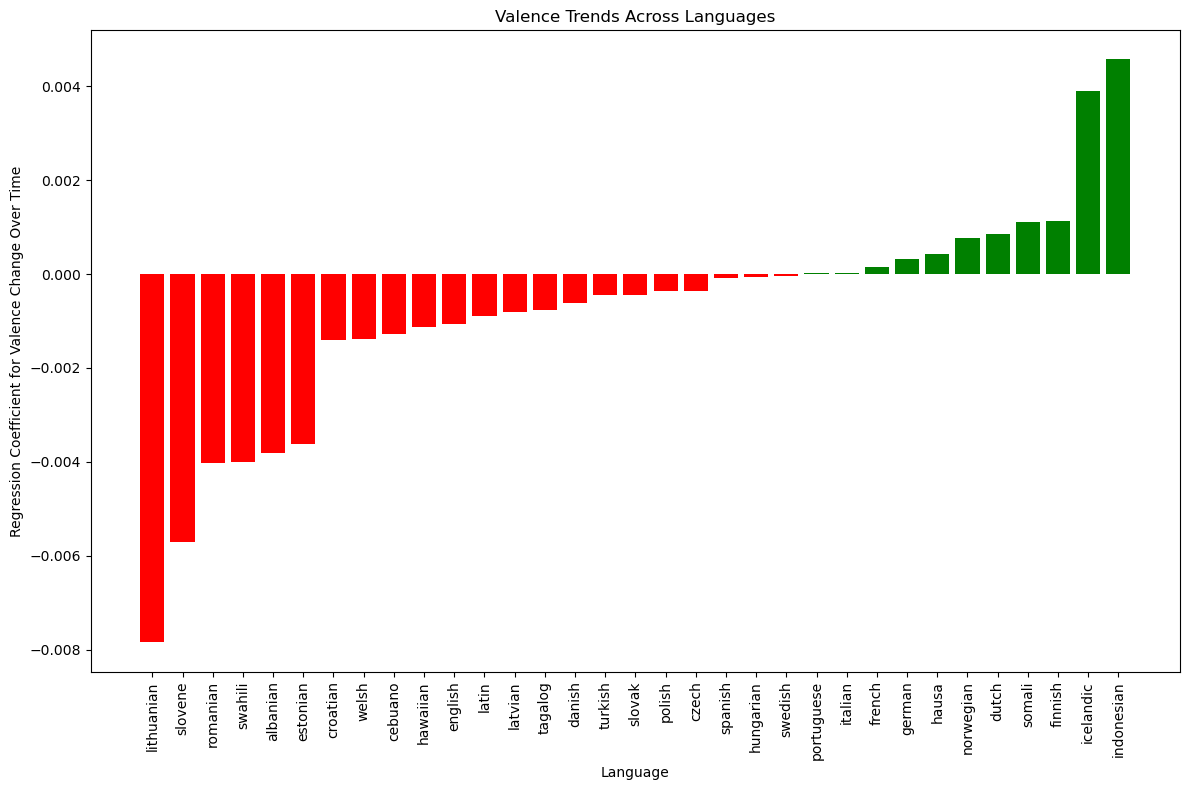

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 读取原始CSV文件
file_path = r"E:\EPFL_Courses\Data_Visualization\lyrical_emotion_trends.csv"
df = pd.read_csv(file_path)

# 创建存储处理后数据的目录
output_dir = r"E:\EPFL_Courses\Data_Visualization\processed_data2"
os.makedirs(output_dir, exist_ok=True)


# 数据清洗
print(f"原始数据行数: {len(df)}")
df = df.dropna(subset=['language', 'publicationYear', 'valence_mean', 'arousal_mean', 'dominance_mean'])
print(f"清洗后数据行数: {len(df)}")

# 限制年份范围，舍弃2024年及以后的数据
df = df[df['publicationYear'] < 2024]
print(f"限制年份后数据行数: {len(df)}")


# 查看语言分布
language_counts = df['language'].value_counts()
print("\n各语言的歌曲数量:")
print(language_counts)

# 设置最小样本量阈值，过滤掉样本太少的语言
min_samples = 50  # 可以根据实际情况调整
valid_languages = language_counts[language_counts >= min_samples].index
df_filtered = df[df['language'].isin(valid_languages)]
print(f"\n筛选后保留的语言数量: {len(valid_languages)}")
print(f"筛选后的数据行数: {len(df_filtered)}")

# 查看筛选后的语言分布
filtered_language_counts = df_filtered['language'].value_counts()
print("\n筛选后各语言的歌曲数量:")
print(filtered_language_counts)

# 按语言分组计算情感指标平均值
language_stats = df_filtered.groupby('language').agg({
    'valence_mean': 'mean',
    'arousal_mean': 'mean',
    'dominance_mean': 'mean'
}).reset_index()

# 添加样本数量列
language_counts = df_filtered['language'].value_counts().reset_index()
language_counts.columns = ['language', 'sample_count']

# 合并统计数据和样本数量
language_stats = language_stats.merge(language_counts, on='language', how='left')

print("\n各语言情感指标平均值:")
print(language_stats.head())

# 保存聚合数据为CSV
agg_output_path = os.path.join(output_dir, "language_emotion_means.csv")
language_stats.to_csv(agg_output_path, index=False)
print(f"\n已保存语言情感均值数据到: {agg_output_path}")

# 为了制作类似于示例图中的回归系数图，我们可以计算每种语言随时间的变化趋势
# 首先确保有发行年份数据
if 'publicationYear' in df.columns:
    # 过滤掉无效年份
    df_trend = df_filtered.dropna(subset=['publicationYear'])
    
    # 定义函数：计算回归系数（情感随时间的变化趋势）
    def calculate_trend(group, emotion_col):
        if len(group) < 10:  # 确保有足够的数据点
            return np.nan
        
        # 简单线性回归：情感 ~ 年份
        x = group['publicationYear'].values
        y = group[emotion_col].values
        
        # 标准化年份以避免数值过大
        x = x - x.mean()
        
        # 如果x全为0，则返回0（避免除以0错误）
        if np.all(x == 0):
            return 0
            
        # 计算斜率 (回归系数)
        slope = np.sum(x * y) / np.sum(x * x)
        return slope
    
    # 为每种语言计算三种情感指标的变化趋势
    language_trends = {}
    
    for language in valid_languages:
        lang_data = df_trend[df_trend['language'] == language]
        
        valence_trend = calculate_trend(lang_data, 'valence_mean')
        arousal_trend = calculate_trend(lang_data, 'arousal_mean')
        dominance_trend = calculate_trend(lang_data, 'dominance_mean')
        
        language_trends[language] = {
            'language': language,
            'valence_trend': valence_trend,
            'arousal_trend': arousal_trend,
            'dominance_trend': dominance_trend,
            'sample_count': len(lang_data)
        }
    
    # 转换为DataFrame
    trends_df = pd.DataFrame.from_dict(language_trends, orient='index').reset_index(drop=True)
    
    # 移除缺失值
    trends_df = trends_df.dropna()
    
    # 按valence趋势排序
    trends_df_valence = trends_df.sort_values('valence_trend')
    trends_df_arousal = trends_df.sort_values('arousal_trend')
    trends_df_dominance = trends_df.sort_values('dominance_trend')
    
    # 保存趋势数据
    trends_output_path = os.path.join(output_dir, "language_emotion_trends.csv")
    trends_df.to_csv(trends_output_path, index=False)
    print(f"\n已保存语言情感趋势数据到: {trends_output_path}")
    
    # 为D3.js可视化准备长格式数据
    # 1. Valence趋势
    valence_viz_data = []
    for _, row in trends_df_valence.iterrows():
        valence_viz_data.append({
            'language': row['language'],
            'trend_value': row['valence_trend'],
            'emotion_type': 'valence',
            'sample_count': row['sample_count']
        })
    
    # 2. Arousal趋势
    arousal_viz_data = []
    for _, row in trends_df_arousal.iterrows():
        arousal_viz_data.append({
            'language': row['language'],
            'trend_value': row['arousal_trend'],
            'emotion_type': 'arousal',
            'sample_count': row['sample_count']
        })
    
    # 3. Dominance趋势
    dominance_viz_data = []
    for _, row in trends_df_dominance.iterrows():
        dominance_viz_data.append({
            'language': row['language'],
            'trend_value': row['dominance_trend'],
            'emotion_type': 'dominance',
            'sample_count': row['sample_count']
        })
    
    # 合并所有趋势数据
    all_trends_viz = valence_viz_data + arousal_viz_data + dominance_viz_data
    trends_viz_df = pd.DataFrame(all_trends_viz)
    
    # 保存可视化用的长格式数据
    viz_output_path = os.path.join(output_dir, "language_emotion_viz_data.csv")
    trends_viz_df.to_csv(viz_output_path, index=False)
    print(f"\n已保存可视化数据到: {viz_output_path}")
    
    # 添加一个示例图，展示valence趋势
    plt.figure(figsize=(12, 8))
    bars = plt.bar(
        trends_df_valence['language'],
        trends_df_valence['valence_trend'],
        color=[
            'red' if x < 0 else 'green' 
            for x in trends_df_valence['valence_trend']
        ]
    )
    plt.title('Valence Trends Across Languages')
    plt.xlabel('Language')
    plt.ylabel('Regression Coefficient for Valence Change Over Time')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    # 保存示例图
    plt.savefig(os.path.join(output_dir, "valence_trends_example.png"))
    print("\n已保存示例图表")
    
else:
    print("\n数据中缺少publicationYear列，无法计算趋势")

# 另外提供静态均值的长格式数据（无趋势，仅均值）
# 将宽格式数据转为长格式
emotion_types = ['valence_mean', 'arousal_mean', 'dominance_mean']
means_long_format = []

for _, row in language_stats.iterrows():
    for emotion in emotion_types:
        means_long_format.append({
            'language': row['language'],
            'emotion_type': emotion.replace('_mean', ''),
            'mean_value': row[emotion],
            'sample_count': row['sample_count']
        })

means_viz_df = pd.DataFrame(means_long_format)

# 保存情感均值的长格式数据
means_viz_output_path = os.path.join(output_dir, "language_emotion_means_viz.csv")
means_viz_df.to_csv(means_viz_output_path, index=False)
print(f"\n已保存情感均值可视化数据到: {means_viz_output_path}")

# 输出一些基本统计信息
print("\n======= 数据洞察 =======")
for emotion in ['valence_mean', 'arousal_mean', 'dominance_mean']:
    emotion_name = emotion.replace('_mean', '')
    avg = language_stats[emotion].mean()
    min_val = language_stats[emotion].min()
    max_val = language_stats[emotion].max()
    min_lang = language_stats.loc[language_stats[emotion].idxmin(), 'language']
    max_lang = language_stats.loc[language_stats[emotion].idxmax(), 'language']
    
    print(f"\n{emotion_name}:")
    print(f"  平均值: {avg:.4f}")
    print(f"  最低值: {min_val:.4f} ({min_lang})")
    print(f"  最高值: {max_val:.4f} ({max_lang})")

if 'publicationYear' in df.columns:
    print("\n情感趋势:")
    for emotion in ['valence_trend', 'arousal_trend', 'dominance_trend']:
        emotion_name = emotion.replace('_trend', '')
        avg = trends_df[emotion].mean()
        min_val = trends_df[emotion].min()
        max_val = trends_df[emotion].max()
        min_lang = trends_df.loc[trends_df[emotion].idxmin(), 'language']
        max_lang = trends_df.loc[trends_df[emotion].idxmax(), 'language']
        
        print(f"\n{emotion_name} 趋势:")
        print(f"  平均趋势: {avg:.6f}")
        print(f"  最负趋势: {min_val:.6f} ({min_lang})")
        print(f"  最正趋势: {max_val:.6f} ({max_lang})")